# 2 — Baseline Models
**Author:** Sai bharath

Trains and evaluates three baselines:
1. **Logistic Regression** (scikit-learn, mean-pooled LLM embeddings)
2. **BiLSTM + Sequential Attention** (PyTorch)
3. **BiGRU + Sequential Attention** (PyTorch)

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from config import (
    EMBEDDINGS_CACHE, LABELS_CACHE, MODELS_DIR, RESULTS_DIR,
    EMBEDDING_DIM, MAX_SENTENCES, HIDDEN_DIM, NUM_CLASSES,
    NUM_LAYERS, DROPOUT, BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY,
    NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import create_splits, make_dataloader
from models import BiLSTMBaseline, BiGRUBaseline
from train_utils import train_one_epoch, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda


In [2]:
embeddings = np.load(EMBEDDINGS_CACHE)
if embeddings.dtype == np.float16:
    embeddings = embeddings.astype(np.float32)
labels = np.load(LABELS_CACHE)
print(f"Embeddings: {embeddings.shape}  Labels: {labels.shape}")

X_train, X_val, X_test, y_train, y_val, y_test = create_splits(
    embeddings, labels, seed=RANDOM_SEED
)
print(f"Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}")

train_loader = make_dataloader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(X_test, y_test, BATCH_SIZE, shuffle=False)

Embeddings: (72095, 16, 384)  Labels: (72095,)
Train: 50,465  Val: 10,815  Test: 10,815


## 2.1 Logistic Regression (mean-pooled embeddings)

In [3]:
# mean-pool sentence embeddings to get one vector per article
X_train_pool = X_train.mean(axis=1)
X_val_pool   = X_val.mean(axis=1)
X_test_pool  = X_test.mean(axis=1)

lr_model = LogisticRegression(
    max_iter=2000, C=1.0, solver="lbfgs",
    class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1,
)
lr_model.fit(X_train_pool, y_train)

lr_preds = lr_model.predict(X_test_pool)
lr_probs = lr_model.predict_proba(X_test_pool)[:, 1]

lr_metrics = {
    "accuracy":  round(accuracy_score(y_test, lr_preds), 4),
    "precision": round(precision_score(y_test, lr_preds, average="weighted"), 4),
    "recall":    round(recall_score(y_test, lr_preds, average="weighted"), 4),
    "f1":        round(f1_score(y_test, lr_preds, average="weighted"), 4),
    "auc":       round(roc_auc_score(y_test, lr_probs), 4),
}
print("Logistic Regression:", lr_metrics)

with open(os.path.join(RESULTS_DIR, "baseline_logreg_metrics.json"), "w") as f:
    json.dump(lr_metrics, f, indent=2)

/home/katarir/Downloads/ai/FINAL/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression: {'accuracy': 0.8805, 'precision': 0.8805, 'recall': 0.8805, 'f1': 0.8805, 'auc': 0.9436}


## 2.2 Helper: train a PyTorch model

In [4]:
def train_pytorch_model(model, name, epochs=NUM_EPOCHS, patience=PATIENCE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_f1, wait = 0.0, 0
    save_path = os.path.join(MODELS_DIR, f"{name}.pt")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss, v_met, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(v_loss)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_met["accuracy"])
        history["val_f1"].append(v_met["f1"])

        print(f"  [{name}] Epoch {epoch:02d}/{epochs}  "
              f"TrLoss={t_loss:.4f}  ValLoss={v_loss:.4f}  "
              f"ValAcc={v_met['accuracy']:.4f}  ValF1={v_met['f1']:.4f}")

        if v_met["f1"] > best_f1:
            best_f1 = v_met["f1"]
            torch.save(model.state_dict(), save_path)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    _, test_met, _, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"  [{name}] Test -> {test_met}")

    with open(os.path.join(RESULTS_DIR, f"{name}_metrics.json"), "w") as f:
        json.dump({"test": test_met, "history": history}, f, indent=2)

    return model, test_met, history

## 2.3 BiLSTM + Sequential Attention

In [5]:
bilstm = BiLSTMBaseline(
    embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT,
)
print(f"BiLSTM params: {sum(p.numel() for p in bilstm.parameters()):,}")

bilstm_model, bilstm_met, bilstm_hist = train_pytorch_model(bilstm, "baseline_bilstm")

BiLSTM params: 1,020,802
  [baseline_bilstm] Epoch 01/20  TrLoss=0.2849  ValLoss=0.2171  ValAcc=0.9143  ValF1=0.9143
  [baseline_bilstm] Epoch 02/20  TrLoss=0.2018  ValLoss=0.2103  ValAcc=0.9176  ValF1=0.9176
  [baseline_bilstm] Epoch 03/20  TrLoss=0.1600  ValLoss=0.1490  ValAcc=0.9434  ValF1=0.9434
  [baseline_bilstm] Epoch 04/20  TrLoss=0.1280  ValLoss=0.1368  ValAcc=0.9468  ValF1=0.9468
  [baseline_bilstm] Epoch 05/20  TrLoss=0.1099  ValLoss=0.1253  ValAcc=0.9562  ValF1=0.9562
  [baseline_bilstm] Epoch 06/20  TrLoss=0.0939  ValLoss=0.1158  ValAcc=0.9585  ValF1=0.9585
  [baseline_bilstm] Epoch 07/20  TrLoss=0.0816  ValLoss=0.1129  ValAcc=0.9601  ValF1=0.9601
  [baseline_bilstm] Epoch 08/20  TrLoss=0.0712  ValLoss=0.1069  ValAcc=0.9613  ValF1=0.9613
  [baseline_bilstm] Epoch 09/20  TrLoss=0.0611  ValLoss=0.1143  ValAcc=0.9619  ValF1=0.9619
  [baseline_bilstm] Epoch 10/20  TrLoss=0.0528  ValLoss=0.1295  ValAcc=0.9610  ValF1=0.9610
  [baseline_bilstm] Epoch 11/20  TrLoss=0.0480  ValLoss

## 2.4 BiGRU + Sequential Attention

In [6]:
bigru = BiGRUBaseline(
    embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT,
)
print(f"BiGRU params: {sum(p.numel() for p in bigru.parameters()):,}")

bigru_model, bigru_met, bigru_hist = train_pytorch_model(bigru, "baseline_bigru")

BiGRU params: 790,402
  [baseline_bigru] Epoch 01/20  TrLoss=0.2682  ValLoss=0.1889  ValAcc=0.9261  ValF1=0.9261
  [baseline_bigru] Epoch 02/20  TrLoss=0.1660  ValLoss=0.1461  ValAcc=0.9421  ValF1=0.9421
  [baseline_bigru] Epoch 03/20  TrLoss=0.1362  ValLoss=0.1346  ValAcc=0.9463  ValF1=0.9462
  [baseline_bigru] Epoch 04/20  TrLoss=0.1187  ValLoss=0.1232  ValAcc=0.9535  ValF1=0.9535
  [baseline_bigru] Epoch 05/20  TrLoss=0.1038  ValLoss=0.1341  ValAcc=0.9522  ValF1=0.9522
  [baseline_bigru] Epoch 06/20  TrLoss=0.0905  ValLoss=0.1196  ValAcc=0.9538  ValF1=0.9538
  [baseline_bigru] Epoch 07/20  TrLoss=0.0804  ValLoss=0.1183  ValAcc=0.9603  ValF1=0.9603
  [baseline_bigru] Epoch 08/20  TrLoss=0.0715  ValLoss=0.1037  ValAcc=0.9618  ValF1=0.9618
  [baseline_bigru] Epoch 09/20  TrLoss=0.0623  ValLoss=0.1093  ValAcc=0.9621  ValF1=0.9621
  [baseline_bigru] Epoch 10/20  TrLoss=0.0549  ValLoss=0.1164  ValAcc=0.9628  ValF1=0.9628
  [baseline_bigru] Epoch 11/20  TrLoss=0.0486  ValLoss=0.1235  ValAc

## 2.5 Baseline comparison

                     accuracy  precision  recall      f1     auc
Model                                                           
Logistic Regression    0.8805     0.8805  0.8805  0.8805  0.9436
BiLSTM + Attention     0.9638     0.9638  0.9638  0.9638  0.9929
BiGRU + Attention      0.9630     0.9631  0.9630  0.9630  0.9928


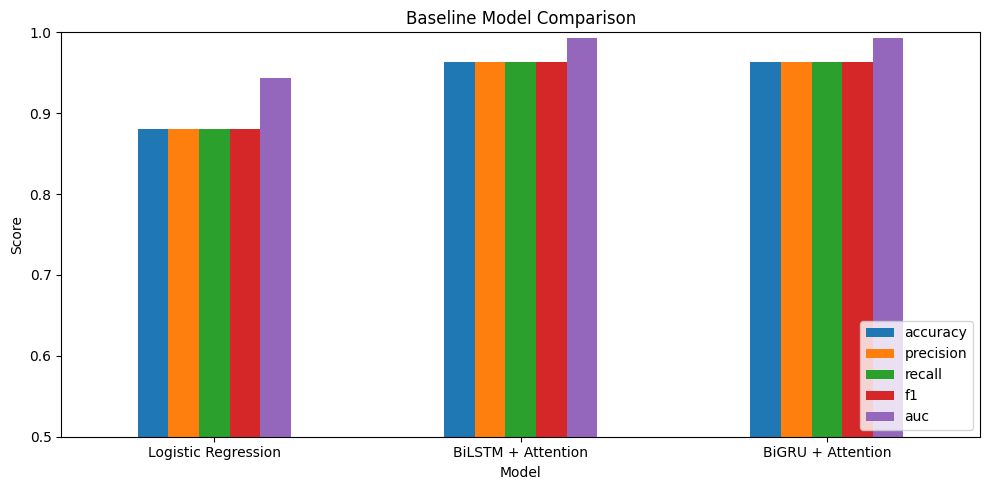

In [7]:
import pandas as pd

rows = [
    {"Model": "Logistic Regression", **lr_metrics},
    {"Model": "BiLSTM + Attention", **bilstm_met},
    {"Model": "BiGRU + Attention", **bigru_met},
]
results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

results_df.plot(kind="bar", figsize=(10, 5), ylim=(0.5, 1.0))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

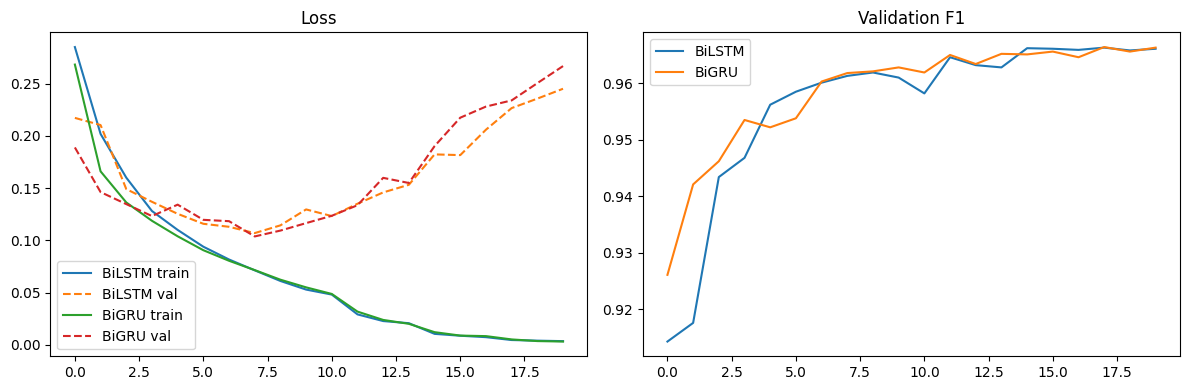

In [8]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for hist, name in [(bilstm_hist, "BiLSTM"), (bigru_hist, "BiGRU")]:
    axes[0].plot(hist["train_loss"], label=f"{name} train")
    axes[0].plot(hist["val_loss"], "--", label=f"{name} val")
    axes[1].plot(hist["val_f1"], label=name)
axes[0].set_title("Loss")
axes[0].legend()
axes[1].set_title("Validation F1")
axes[1].legend()
plt.tight_layout()
plt.show()